# **Imports**

In [2]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score

# **Load Dataset**

In [3]:
train_path = (r"D:\Demis2\Data-regression\train.csv")
test_path = (r"D:\Demis2\Data-regression\test.csv")

## Train

In [104]:
df_train = pd.read_csv(train_path)
df_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.4817,6,4.443645,1.134293,1397,3.350120,36.77,-119.84,0.720
1,6.9133,8,5.976471,1.026471,862,2.535294,33.68,-117.80,2.741
2,1.5536,25,4.088785,1.000000,931,4.350467,36.60,-120.19,0.583
3,1.5284,31,2.740088,1.008811,597,2.629956,34.10,-118.32,2.000
4,4.0815,21,5.166667,1.002688,1130,3.037634,37.79,-121.23,1.179
...,...,...,...,...,...,...,...,...,...
16507,3.0625,20,5.860000,1.112000,745,2.980000,39.59,-121.90,0.938
16508,2.6133,49,5.163755,1.100437,1131,2.469432,38.11,-122.25,1.031
16509,4.4958,19,5.899767,1.074592,1206,2.811189,38.92,-121.22,1.926
16510,2.5750,39,3.591203,1.086675,2546,3.293661,34.16,-118.14,1.535


In [106]:
df_train = pd.read_csv(train_path)
x_train = df_train.drop('MedHouseVal', axis=1)
y_train = df_train['MedHouseVal']

In [107]:
y_train.head()

0    0.720
1    2.741
2    0.583
3    2.000
4    1.179
Name: MedHouseVal, dtype: float64

## Test

In [108]:
df_test = pd.read_csv(test_path)
x_test = df_test.drop('MedHouseVal', axis=1)
y_test = df_test['MedHouseVal']

# **Preprocessing**

## Convert to tensor

### Train

In [109]:
x_train.values.shape

(16512, 8)

In [110]:
x_train = torch.tensor(x_train.values, dtype=torch.float32)

In [111]:
y_train = torch.tensor(y_train.values, dtype=torch.float32)

### Test

In [112]:
x_test = torch.FloatTensor(x_test.values)
y_test = torch.FloatTensor(y_test.values)

## Normalize

In [113]:
mu = x_train.mean(dim=0)
std = x_train.std(dim=0)

In [114]:
x_train = (x_train - mu) / std

In [116]:
print(x_train.min())

tensor(-2.3870)


In [ ]:
x_train.std(dim=0)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [119]:
print(x_train.min())
print(x_train.max())

tensor(-2.3870)
tensor(113.4342)


In [117]:
x_test = (x_test - mu) / std

In [118]:
print(x_test.min())

tensor(-2.3620)


In [ ]:
x_test.mean(dim=0)

tensor([ 0.0174,  0.0059,  0.0357,  0.0232, -0.0412, -0.0045,  0.0125, -0.0141])

In [ ]:
x_test.std(dim=0)

tensor([1.0173, 0.9952, 1.3752, 1.2463, 0.8829, 0.7154, 0.9926, 0.9963])

# **Dataloader**

In [120]:
train_dataset = TensorDataset(x_train, y_train)

In [121]:
train_dataset

In [ ]:
train_dataset.tensors[1]

tensor([0.7200, 2.7410, 0.5830,  ..., 1.9260, 1.5350, 0.8110])

In [122]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [ ]:
train_loader

In [123]:
for i, (x_batch, y_batch) in enumerate(train_loader):
  print(i, x_batch.shape, y_batch.shape)

0 torch.Size([128, 8]) torch.Size([128])
1 torch.Size([128, 8]) torch.Size([128])
2 torch.Size([128, 8]) torch.Size([128])
3 torch.Size([128, 8]) torch.Size([128])
4 torch.Size([128, 8]) torch.Size([128])
5 torch.Size([128, 8]) torch.Size([128])
6 torch.Size([128, 8]) torch.Size([128])
7 torch.Size([128, 8]) torch.Size([128])
8 torch.Size([128, 8]) torch.Size([128])
9 torch.Size([128, 8]) torch.Size([128])
10 torch.Size([128, 8]) torch.Size([128])
11 torch.Size([128, 8]) torch.Size([128])
12 torch.Size([128, 8]) torch.Size([128])
13 torch.Size([128, 8]) torch.Size([128])
14 torch.Size([128, 8]) torch.Size([128])
15 torch.Size([128, 8]) torch.Size([128])
16 torch.Size([128, 8]) torch.Size([128])
17 torch.Size([128, 8]) torch.Size([128])
18 torch.Size([128, 8]) torch.Size([128])
19 torch.Size([128, 8]) torch.Size([128])
20 torch.Size([128, 8]) torch.Size([128])
21 torch.Size([128, 8]) torch.Size([128])
22 torch.Size([128, 8]) torch.Size([128])
23 torch.Size([128, 8]) torch.Size([128])
24

In [23]:
len(train_loader)

129

In [ ]:
x_b, y_b = next(iter(train_loader))

In [26]:
test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# **Define Model**

In [124]:
num_feats = 8
out_feat = 1
h1 = 64
h2 = 32

model = nn.Sequential(nn.Linear(num_feats, h1),
                      nn.ReLU(),
                      nn.Linear(h1, h2),
                      nn.ReLU(),
                      nn.Linear(h2, out_feat))

In [125]:
model

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

# **Loss & Optimizer**

In [126]:
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001)

In [94]:
for x_batch, y_batch in train_loader:
    yp = model(x_batch)

    print("output:", yp[:5])
    print("has nan:", torch.isnan(yp).any())
    print("has inf:", torch.isinf(yp).any())

    break

output: tensor([[-41.7466],
        [-77.7347],
        [-33.0610],
        [-59.1723],
        [-79.3321]], grad_fn=<SliceBackward0>)
has nan: tensor(False)
has inf: tensor(False)


# **Train Loooooop!**

In [127]:
num_epochs = 200
loss_train_hist, loss_test_hist = [], []

for epoch in range(num_epochs):
  loss_train = 0
  for x_batch, y_batch in train_loader:
    yp = model(x_batch)
    loss = loss_fn(yp.squeeze(), y_batch)
    loss_train += loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  loss_test = 0
  for x_batch, y_batch in test_loader:
    yp = model(x_batch)
    loss_test += loss_fn(yp.squeeze(), y_batch)

  loss_total_train = loss_train/len(train_loader)
  loss_total_test = loss_test/len(test_loader)

  loss_train_hist.append(loss_total_train.item())
  loss_test_hist.append(loss_total_test.item())

  if epoch % 10 == 0:
    print(f'Epoch = {epoch} : Loss Train = {loss_total_train:.4}')
    print(f'Epoch = {epoch} : Loss Test = {loss_total_test:.4}')
    print()

Epoch = 0 : Loss Train = 5.631
Epoch = 0 : Loss Test = 5.403

Epoch = 10 : Loss Train = 1.702
Epoch = 10 : Loss Test = 1.601

Epoch = 20 : Loss Train = 1.001
Epoch = 20 : Loss Test = 0.9731

Epoch = 30 : Loss Train = 0.8457
Epoch = 30 : Loss Test = 0.8292

Epoch = 40 : Loss Train = 0.7621
Epoch = 40 : Loss Test = 0.7549

Epoch = 50 : Loss Train = 0.714
Epoch = 50 : Loss Test = 0.7139

Epoch = 60 : Loss Train = 0.6841
Epoch = 60 : Loss Test = 0.6892

Epoch = 70 : Loss Train = 0.664
Epoch = 70 : Loss Test = 0.6722

Epoch = 80 : Loss Train = 0.6482
Epoch = 80 : Loss Test = 0.6587

Epoch = 90 : Loss Train = 0.6349
Epoch = 90 : Loss Test = 0.6468

Epoch = 100 : Loss Train = 0.6232
Epoch = 100 : Loss Test = 0.636

Epoch = 110 : Loss Train = 0.6124
Epoch = 110 : Loss Test = 0.6258

Epoch = 120 : Loss Train = 0.6024
Epoch = 120 : Loss Test = 0.616

Epoch = 130 : Loss Train = 0.593
Epoch = 130 : Loss Test = 0.6067

Epoch = 140 : Loss Train = 0.5842
Epoch = 140 : Loss Test = 0.5978

Epoch = 150 

# **Learning Curve**

In [128]:
loss_train_hist = torch.tensor(loss_train_hist).cpu().detach().numpy()
loss_test_hist = torch.tensor(loss_test_hist).cpu().numpy()

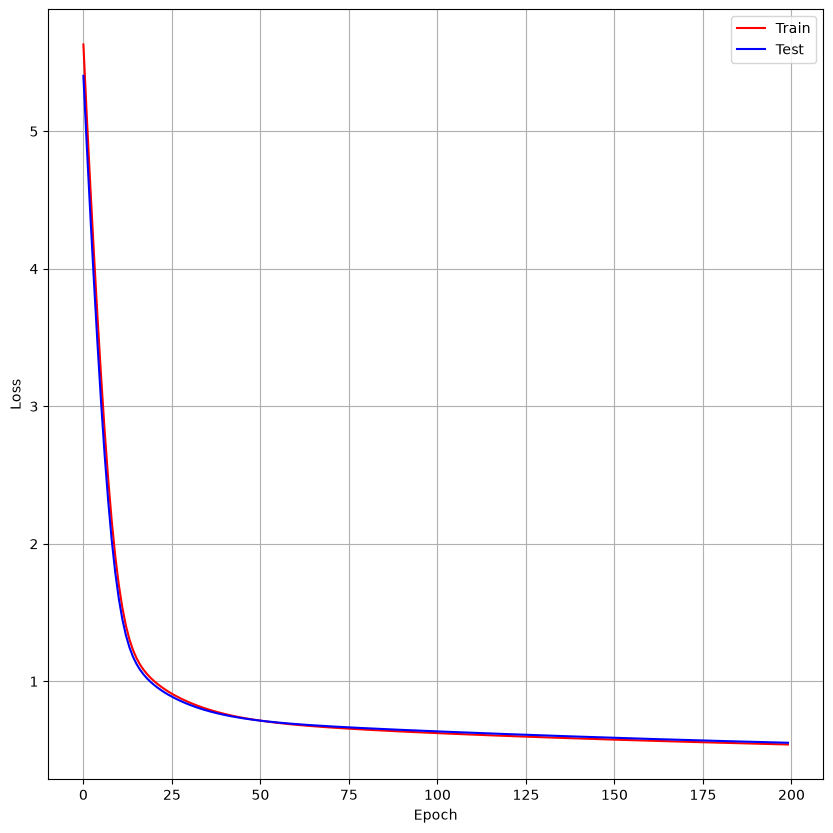

In [129]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(range(num_epochs), loss_train_hist, 'r-', label='Train')
ax.plot(range(num_epochs), loss_test_hist, 'b-', label='Test')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True)
ax.legend()

# **Prediction**

In [ ]:
yp_total = []
yt_total = []

with torch.no_grad():
  for x, y in test_loader:
    yp = model(x)
    yp_total.append(yp.squeeze())
    yt_total.append(y)

In [ ]:
yp_total = torch.cat(yp_total)
yt_total = torch.cat(yt_total)

In [ ]:
r2_score(yt_total, yp_total)

0.7440685700284603

In [ ]:
yp_total[:5], yt_total[:5]

(tensor([3.0283, 1.5122, 1.0367, 3.1155, 3.8536]),
 tensor([2.7870, 2.0760, 0.9670, 3.5380, 3.9050]))